# Outliers, Correlação, Causalidade e Hipóteses Estatísticas

**Atividade:** Identificação de outliers · Tipos de correlação · Correlação vs. causalidade · Hipóteses estatísticas  
**Dataset:** Retornos diários do Ibovespa (^BVSP) e do S&P 500 (^GSPC)  
**Fonte:** Yahoo Finance via `yfinance`

---

## Contexto

Quatro perguntas que aparecem em quase todo problema de risco no mercado de capitais:

| Tema | Pergunta prática |
|------|------------------|
| **Outliers** | Esse retorno de -12% é erro de dado, evento raro ou regime novo? |
| **Correlação** | Quando dois ativos se movem juntos, qual a força e o tipo dessa relação? |
| **Correlação × causalidade** | A correlação que observei autoriza alguma decisão? |
| **Hipóteses estatísticas** | Como decido entre 'efeito real' e 'flutuação amostral' com rigor? |

Cada seção combina teoria, intuição geométrica e aplicação direta aos dados.

## 1. Bibliotecas e dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

In [2]:
# Baixa preços de fechamento ajustado e calcula retornos log diários
tickers = ['^BVSP', '^GSPC']
precos = yf.download(tickers, start='2010-01-01', end='2025-12-31', auto_adjust=True)['Close']
precos.columns = ['Ibovespa', 'SP500']

retornos = np.log(precos / precos.shift(1)).dropna()
retornos.describe()

[*********************100%***********************]  2 of 2 completed


,Ibovespa,SP500
count,3620.000000,3620.000000
mean,0.000249,0.000490
std,0.014630,0.011030
min,-0.159930,-0.127652
25%,-0.007462,-0.003797
50%,0.000362,0.000741
75%,0.008251,0.005707
max,0.130223,0.090895


## 2. Outliers — como identificar

Um **outlier** é uma observação que se afasta significativamente do restante dos dados. No mercado financeiro, identificá-los corretamente é crítico: tratar um *crash* real como ruído subestima risco; tratar um erro de dado como evento real polui o modelo.

Antes de remover qualquer ponto, é preciso responder:

1. **É erro de medição?** (preço travado, divisão por ação não ajustada, vírgula no lugar errado)
2. **É evento raro mas legítimo?** (15/05/2017 — "Joesley Day"; 12/03/2020 — choque COVID)
3. **É indicação de regime novo?** (mudança estrutural — crise, intervenção do BC)

Existem várias técnicas; nenhuma é universal. Vamos comparar quatro.

### 2.1 Regra do desvio-padrão (z-score)

$$ z_i = \frac{x_i - \bar{x}}{s} $$

Pontos com $|z| > 3$ são tradicionalmente marcados como outliers. **Limitação:** assume distribuição aproximadamente normal e a própria média/desvio são contaminados pelo outlier (não é robusto).

In [3]:
ibov = retornos['Ibovespa']
z = (ibov - ibov.mean()) / ibov.std()
outliers_z = ibov[np.abs(z) > 3]
print(f'Total de observações: {len(ibov)}')
print(f'Outliers por z-score (|z|>3): {len(outliers_z)}')
outliers_z.sort_values().head(5)

Total de observações: 3620
Outliers por z-score (|z|>3): 35


Date
2020-03-12   -0.159930
2020-03-16   -0.149910
2020-03-09   -0.129811
2020-03-18   -0.109244
2017-05-18   -0.092107
Name: Ibovespa, dtype: float64

### 2.2 Regra do IQR (Tukey)

Mais robusta que o z-score, pois usa **mediana e quartis** — não é puxada por valores extremos.

$$ \text{IQR} = Q_3 - Q_1 $$

São outliers os pontos fora de $[Q_1 - 1{,}5 \cdot \text{IQR},\; Q_3 + 1{,}5 \cdot \text{IQR}]$.  
Para distribuições com cauda pesada (como retornos financeiros), costuma-se usar 3·IQR para 'outliers extremos'.

In [4]:
q1, q3 = ibov.quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_iqr = ibov[(ibov < lim_inf) | (ibov > lim_sup)]
print(f'Limites IQR: [{lim_inf:.4f}, {lim_sup:.4f}]')
print(f'Outliers por IQR: {len(outliers_iqr)}')

Limites IQR: [-0.0310, 0.0318]
Outliers por IQR: 108


### 2.3 MAD (Median Absolute Deviation)

Versão robusta do z-score: substitui média por mediana e desvio por MAD.

$$ \text{MAD} = \text{mediana}(|x_i - \tilde{x}|), \quad z^{\text{rob}}_i = \frac{0{,}6745 (x_i - \tilde{x})}{\text{MAD}} $$

O fator 0,6745 calibra o MAD para coincidir com o desvio-padrão sob normalidade. Marca outliers em $|z^{\text{rob}}| > 3{,}5$.

In [5]:
mediana = ibov.median()
mad = (ibov - mediana).abs().median()
z_rob = 0.6745 * (ibov - mediana) / mad
outliers_mad = ibov[np.abs(z_rob) > 3.5]
print(f'Outliers por MAD: {len(outliers_mad)}')

Outliers por MAD: 41


### 2.4 Inspeção visual — boxplot e histograma

Métodos automatizados nunca substituem o olhar. Boxplot mostra os 'pontos soltos'; histograma mostra se há **bimodalidade** (dois regimes) ou apenas caudas pesadas.

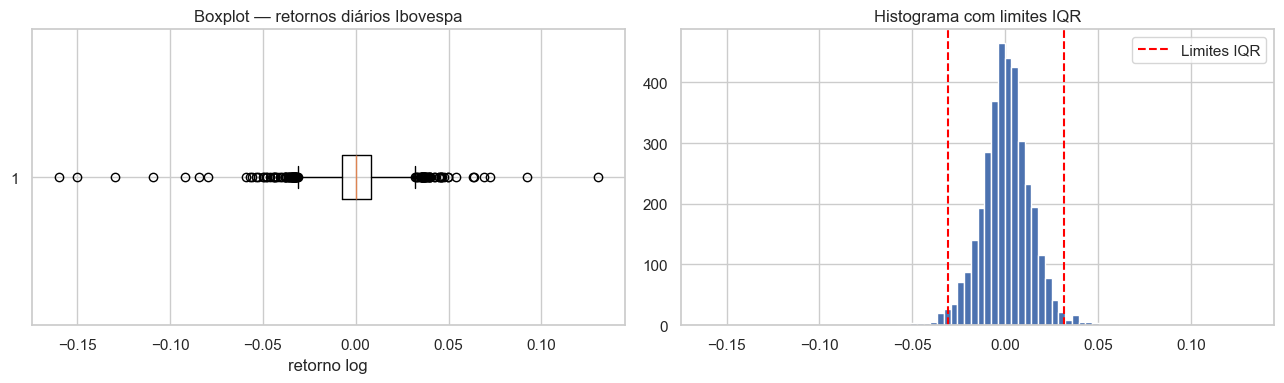

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].boxplot(ibov, vert=False)
axes[0].set_title('Boxplot — retornos diários Ibovespa')
axes[0].set_xlabel('retorno log')

axes[1].hist(ibov, bins=80, edgecolor='white')
axes[1].axvline(lim_inf, color='red', ls='--', label='Limites IQR')
axes[1].axvline(lim_sup, color='red', ls='--')
axes[1].set_title('Histograma com limites IQR')
axes[1].legend()
plt.tight_layout()
plt.show()

### 2.5 Comparação dos métodos

| Método | Robusto a outliers? | Pressupõe normalidade? | Quando usar |
|--------|---------------------|------------------------|-------------|
| Z-score | Não | Sim | Dados aproximadamente normais e poucos outliers |
| IQR (Tukey) | Sim | Não | Distribuições assimétricas; análise exploratória |
| MAD | Sim (mais que IQR) | Não | Dados com caudas muito pesadas |
| Inspeção visual | — | Não | Sempre, em conjunto com os anteriores |

> **Decisão importante:** identificar ≠ remover. Em séries financeiras, os outliers *carregam o risco* — removê-los esconde o que o modelo precisa aprender. A regra é **investigar**, e só remover se for erro de dado.

## 3. Tipos de correlação

Correlação mede o grau de **associação** entre duas variáveis. Existem várias definições, e usar a errada gera conclusões erradas.

### 3.1 Pearson — correlação linear

$$ \rho_{XY} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} \in [-1, 1] $$

Mede **dependência linear**. Pressupõe relação aproximadamente linear e variáveis numéricas. Sensível a outliers.

### 3.2 Spearman — correlação por postos (rank)

É a correlação de Pearson aplicada aos **postos** (rankings) das observações. Captura **monotonicidade** (cresce junto, mesmo que não linearmente). Robusta a outliers e funciona com variáveis ordinais.

### 3.3 Kendall (τ) — concordância por pares

Conta a fração de pares de observações que são *concordantes* menos a fração de *discordantes*. Mais robusta ainda em amostras pequenas, mas computacionalmente mais cara.

### 3.4 Resumo prático

| Coeficiente | Mede | Sensível a outliers | Pressupostos |
|-------------|------|---------------------|--------------|
| Pearson | Relação **linear** | Sim | Variáveis numéricas, aprox. normais |
| Spearman | Relação **monotônica** | Não | Variáveis ordinais ou contínuas |
| Kendall (τ) | Concordância de pares | Não | Idem Spearman; preferido em $n$ pequeno |

In [7]:
p = retornos.corr(method='pearson').iloc[0, 1]
s = retornos.corr(method='spearman').iloc[0, 1]
k = retornos.corr(method='kendall').iloc[0, 1]
print(f'Pearson : {p:.4f}')
print(f'Spearman: {s:.4f}')
print(f'Kendall : {k:.4f}')

Pearson : 0.5710
Spearman: 0.4608
Kendall : 0.3239


### 3.5 Por que olhar o gráfico antes do número — Anscombe

Quatro datasets clássicos com **mesma média, mesma variância e mesma correlação de Pearson (~0,816)** mas formatos completamente diferentes. A moral: o coeficiente sozinho engana.

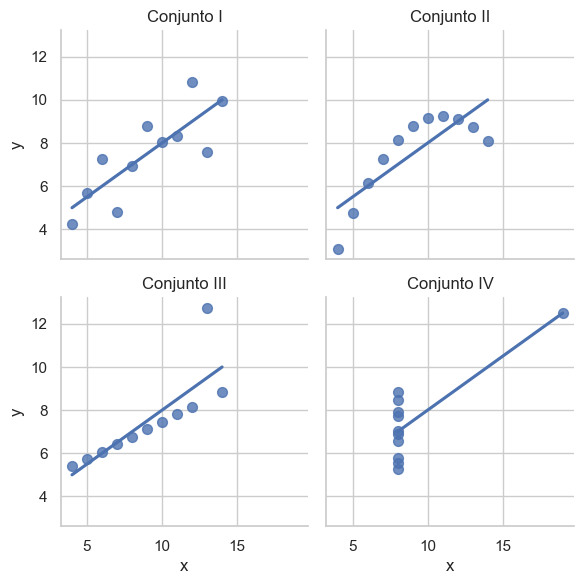

dataset
I      0.816421
II     0.816237
III    0.816287
IV     0.816521
Name: Pearson, dtype: float64

In [8]:
anscombe = sns.load_dataset('anscombe')
g = sns.lmplot(data=anscombe, x='x', y='y', col='dataset', col_wrap=2,
               ci=None, height=3, scatter_kws={'s': 50, 'alpha': 0.8})
g.set_titles('Conjunto {col_name}')
plt.show()
anscombe.groupby('dataset').apply(lambda d: d[['x','y']].corr().iloc[0,1]).rename('Pearson')

### 3.6 Correlação não é estática — janelas móveis

A correlação entre Ibovespa e S&P 500 muda com o tempo. Em crises globais ela tende a 1 ('quando a maré desce, todos os barcos descem'); em períodos calmos, descola. Por isso medir correlação em janela móvel é prática padrão em risco.

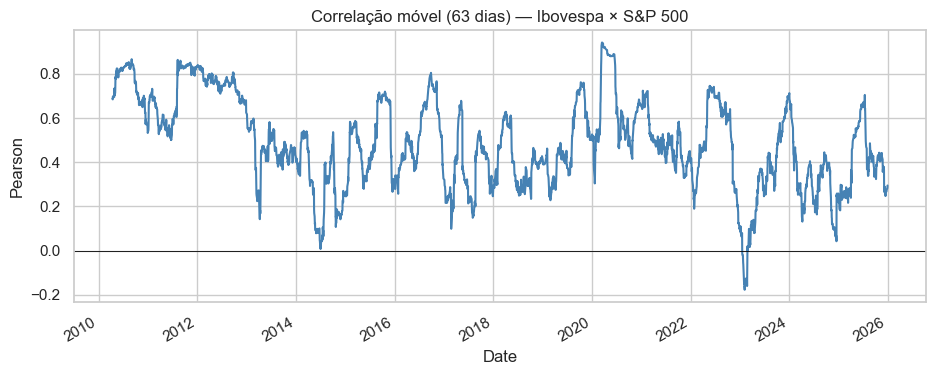

In [9]:
corr_movel = retornos['Ibovespa'].rolling(63).corr(retornos['SP500'])  # ~3 meses
corr_movel.plot(figsize=(11, 4), color='steelblue')
plt.axhline(0, color='black', lw=0.6)
plt.title('Correlação móvel (63 dias) — Ibovespa × S&P 500')
plt.ylabel('Pearson')
plt.show()

## 4. Correlação ≠ Causalidade

Talvez a confusão mais cara em ciência de dados aplicada. Correlação alta entre $X$ e $Y$ pode ter pelo menos **cinco origens**:

1. $X$ causa $Y$ — *o efeito que se espera demonstrar*
2. $Y$ causa $X$ — **causalidade reversa**
3. $Z$ causa ambos — **confundidor (lurking variable)**
4. **Acaso** — flutuação amostral, especialmente em $n$ pequeno
5. **Viés de seleção** — a amostra foi construída de um jeito que força a correlação

### 4.1 Exemplos folclóricos (correlações espúrias)

- Vendas de sorvete e afogamentos: ambos crescem no verão → **confundidor (temperatura)**.
- Número de filmes do Nicolas Cage e afogamentos em piscinas: $r \approx 0{,}66$ → **acaso** (Tyler Vigen).
- Países com mais chocolate per capita ganham mais Nobel: **confundidor (PIB e investimento em educação)**.

### 4.2 No mercado financeiro

- Retorno do Ibovespa e fluxo estrangeiro: correlacionados, mas **causalidade ambígua** (preço sobe atrai fluxo, fluxo empurra preço).
- Volume e volatilidade: correlação positiva, mas **ambos respondem ao mesmo choque informacional** (notícia, decisão de juros).

### 4.3 Como subir de correlação para causalidade

| Ferramenta | Ideia |
|-----------|-------|
| **Experimento aleatorizado (RCT)** | Sortear quem recebe o tratamento; padrão-ouro |
| **Quasi-experimentos** | Diferenças-em-diferenças, descontinuidade de regressão |
| **Variáveis instrumentais** | Achar uma variável que afeta $Y$ só *via* $X$ |
| **Causalidade de Granger** | $X$ ajuda a prever $Y$ além do passado de $Y$ (predição, não causa física) |
| **DAGs (Pearl)** | Modelar explicitamente as relações causais e testá-las |

> **Regra de bolso:** sem desenho de pesquisa que controle confundidores, qualquer afirmação causal a partir de dados observacionais é uma hipótese, não uma conclusão.

In [10]:
# Demonstração: variável Z confundidora gera correlação espúria entre X e Y
n = 500
Z = np.random.normal(size=n)            # confundidor (ex.: 'humor do mercado global')
X = 0.8 * Z + np.random.normal(size=n)  # influenciada por Z
Y = 0.8 * Z + np.random.normal(size=n)  # influenciada por Z (sem ligação direta com X)

r_bruto = np.corrcoef(X, Y)[0, 1]

# Correlação parcial: removendo o efeito de Z em ambos
rx = X - np.polyval(np.polyfit(Z, X, 1), Z)
ry = Y - np.polyval(np.polyfit(Z, Y, 1), Z)
r_parcial = np.corrcoef(rx, ry)[0, 1]

print(f'Correlação bruta X,Y         : {r_bruto:.3f}')
print(f'Correlação parcial controlando Z: {r_parcial:.3f}')

Correlação bruta X,Y         : 0.392
Correlação parcial controlando Z: 0.072


## 5. Hipóteses estatísticas

Um **teste de hipótese** é um procedimento formal para decidir, a partir de uma amostra, entre duas afirmações sobre a população.

### 5.1 H₀ e H₁

- **Hipótese nula (H₀)**: o status quo, 'não há efeito', 'média = valor', 'duas distribuições são iguais'.
- **Hipótese alternativa (H₁)**: o que se quer evidenciar.

Exemplo:  H₀: a média do retorno do Ibovespa é zero · H₁: é diferente de zero.

### 5.2 Estatística de teste, p-valor e nível de significância

1. Calcula-se uma **estatística de teste** ($T$) a partir da amostra.
2. Sob H₀, $T$ tem uma distribuição conhecida (t, normal, χ², F, ...).
3. O **p-valor** é a probabilidade, *assumindo H₀ verdadeira*, de observar um $T$ tão ou mais extremo que o observado.
4. Define-se a priori um **nível de significância** $\alpha$ (tipicamente 0,05).
5. Decisão: **se $p < \alpha$, rejeita H₀**; caso contrário, não rejeita.

> ⚠️ **O que p-valor NÃO é:** não é a probabilidade de H₀ ser verdadeira. Não é o tamanho do efeito. Um p pequeno em $n$ enorme pode esconder efeito desprezível.

### 5.3 Erros tipo I e tipo II

|  | H₀ verdadeira | H₀ falsa |
|---|---|---|
| Rejeito H₀ | **Erro tipo I** (α — falso positivo) | Decisão correta (poder = 1−β) |
| Não rejeito | Decisão correta | **Erro tipo II** (β — falso negativo) |

Reduzir α aumenta β; só se aumenta o **poder** com mais dados ou efeito maior.

### 5.4 Receita de bolo de qualquer teste

1. Definir H₀ e H₁ **antes** de olhar os dados.
2. Escolher $\alpha$.
3. Verificar pressupostos do teste (normalidade, independência, variâncias iguais...).
4. Calcular estatística e p-valor.
5. Decidir e **reportar tamanho de efeito + intervalo de confiança**, não só o p.

### 5.5 Aplicação 1 — Teste t para uma média

**Pergunta:** o retorno médio diário do Ibovespa é estatisticamente diferente de zero?

- H₀: $\mu = 0$
- H₁: $\mu \neq 0$
- Estatística: $t = \dfrac{\bar{x} - 0}{s / \sqrt{n}}$

In [11]:
t_stat, p_val = stats.ttest_1samp(ibov, popmean=0)
ic_inf = ibov.mean() - 1.96 * ibov.std() / np.sqrt(len(ibov))
ic_sup = ibov.mean() + 1.96 * ibov.std() / np.sqrt(len(ibov))
print(f'média diária : {ibov.mean():.6f}')
print(f'IC 95%       : [{ic_inf:.6f}, {ic_sup:.6f}]')
print(f't            : {t_stat:.4f}')
print(f'p-valor      : {p_val:.4f}')
print('→ rejeita H₀' if p_val < 0.05 else '→ não rejeita H₀')

média diária : 0.000249
IC 95%       : [-0.000227, 0.000726]
t            : 1.0259
p-valor      : 0.3050
→ não rejeita H₀


### 5.6 Aplicação 2 — Teste de normalidade (Shapiro-Wilk / Jarque-Bera)

**Pergunta:** os retornos do Ibovespa seguem uma distribuição normal? (resposta esperada: não — caudas pesadas)

- H₀: a amostra vem de uma distribuição normal
- H₁: não vem

In [12]:
jb_stat, jb_p = stats.jarque_bera(ibov)
print(f'Jarque-Bera : {jb_stat:.2f}  | p-valor: {jb_p:.4g}')
print('→ rejeita normalidade' if jb_p < 0.05 else '→ não rejeita normalidade')

Jarque-Bera : 25911.32  | p-valor: 0
→ rejeita normalidade


### 5.7 Aplicação 3 — Significância de uma correlação

Toda correlação amostral é uma estimativa. Faz sentido perguntar: **a correlação na população é mesmo diferente de zero, ou esse $r$ que observei é só ruído?**

- H₀: $\rho = 0$
- H₁: $\rho \neq 0$

In [13]:
r, p_corr = stats.pearsonr(retornos['Ibovespa'], retornos['SP500'])
print(f'Pearson Ibov × SP500: r = {r:.4f}  | p-valor: {p_corr:.4g}')

Pearson Ibov × SP500: r = 0.5710  | p-valor: 2.105e-312


## 6. Síntese

| Conceito | O que reter |
|---|---|
| **Outliers** | Identificar com z-score, IQR, MAD e **olhar o gráfico**. Em finanças, raramente remover — eles são o risco. |
| **Correlação** | Pearson = linear · Spearman = monotônica · Kendall = concordância. Sempre acompanhar de gráfico (lição de Anscombe) e considerar dinâmica temporal. |
| **Causalidade** | Correlação é *condição necessária, não suficiente*. Cuidado com confundidores, causalidade reversa, viés de seleção e acaso. |
| **Hipóteses** | Definir H₀/H₁ antes, escolher α, checar pressupostos, reportar **tamanho de efeito e IC** junto do p-valor. |

> **Mensagem final:** estatística rigorosa não responde 'é verdade?'; ela responde 'a evidência é forte o bastante para mudar minha aposta?'. Em risco financeiro, essa diferença é tudo.